clasificacion multiclase de imagenes de insectos - carabid beetles (natural history museum london)

dataset: Insect Identification from Habitus Images (carabid beetles). fuente: kaggle - kmldas/insect-identification-from-habitus-images. paper original: Hansen et al. 2020, Ecology and Evolution. 291 especies de escarabajos carabidos, 63364 imagenes de especimenes escaneados en alta resolucion, a color. el objetivo es que el modelo mire la imagen del especimen y diga de que especie es. comparamos 3 modelos: una cnn con conexiones residuales entrenada desde cero (con data augmentation), una swin transformer tiny preentrenada con transfer learning (backbone congelado), y la misma swin transformer con fine-tuning completo (todo descongelado).

In [ ]:
# librerias base: numpy/pandas para datos, matplotlib para graficos,
# torch/torchvision para el modelo, sklearn para metricas, PIL para abrir imagenes, tqdm para barra de progreso
import os, glob, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from PIL import Image
from tqdm import tqdm

# semilla fija para que la particion de datos y la inicializacion de pesos sean reproducibles
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# usamos gpu si esta disponible, si no cae a cpu (mucho mas lento, avisamos si pasa esto)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type != 'cuda':
    print('OJO: no hay gpu activa, activar en entorno de ejecucion antes de seguir')
device

device(type='cuda')

descarga del dataset: directo de kaggle al disco local de colab (/content), no pasa por drive en ningun momento. asi evitamos el problema de lectura lenta que tuvimos con rice (leer muchos archivos chicos desde drive es lento, disco local no).

In [ ]:
# kagglehub baja el dataset y lo descomprime directo en el disco local de colab
!pip install kagglehub -q
import kagglehub
DATASET_PATH = kagglehub.dataset_download("kmldas/insect-identification-from-habitus-images")
print(DATASET_PATH)

100%|██████████| 2.38G/2.38G [00:20<00:00, 122MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/kmldas/insect-identification-from-habitus-images/versions/1


chequeo de estructura: buscamos automaticamente en que carpeta estan realmente las 291 especies (a veces el dataset viene con una carpeta contenedora de mas antes de llegar a las carpetas de clases, por eso no asumimos el path a mano).

In [ ]:
# recorremos el arbol de carpetas buscando el nivel donde hay muchas subcarpetas (>20)
# y esas subcarpetas contienen imagenes adentro. ese nivel es el que tiene las especies.
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')

def find_class_root(base):
    for root, dirs, files in os.walk(base):
        if len(dirs) > 20:
            sample_dir = os.path.join(root, dirs[0])
            sample_files = [f for f in os.listdir(sample_dir) if f.lower().endswith(IMG_EXTS)]
            if sample_files:
                return root
    return base  # si no encuentra nada mejor, devuelve la base tal cual

CLASS_ROOT = find_class_root(DATASET_PATH)
print('carpeta real donde estan las clases:', CLASS_ROOT)
print('subcarpetas encontradas ahi:', len(os.listdir(CLASS_ROOT)))

carpeta real donde estan las clases: /root/.cache/kagglehub/datasets/kmldas/insect-identification-from-habitus-images/versions/1/database
subcarpetas encontradas ahi: 291


contamos cuantas imagenes tiene cada clase, para decidir el filtro de minimo/maximo por clase.

In [ ]:
# listamos cada carpeta de especie (clase) y contamos sus imagenes
class_dirs_all = sorted([d for d in glob.glob(os.path.join(CLASS_ROOT, '*')) if os.path.isdir(d)])
counts = {}
for d in class_dirs_all:
    n_files = len([f for f in os.listdir(d) if f.lower().endswith(IMG_EXTS)])
    counts[os.path.basename(d)] = n_files

print('cantidad de clases encontradas:', len(class_dirs_all))
pd.Series(counts).describe()

cantidad de clases encontradas: 291


,0
count,291.000000
mean,217.745704
std,152.295597
min,50.000000
25%,111.500000
50%,170.000000
75%,285.500000
max,888.000000


filtramos clases con muy pocas imagenes y capamos las que tienen demasiadas, para que quede balanceado y no tarde horas entrenar. si el total termina siendo menor a 20000 (el minimo pedido), bajamos MIN_PER_CLASS o subimos MAX_PER_CLASS y volvemos a correr esta celda.

In [ ]:
MIN_PER_CLASS = 80   # clases con menos que esto se descartan (muy pocas imagenes para aprender bien)
MAX_PER_CLASS = 200   # clases con mas que esto se recortan (para que no dominen el entrenamiento)

paths, labels = [], []
kept_classes = []

for d in class_dirs_all:
    files = [f for f in glob.glob(os.path.join(d, '*.*')) if f.lower().endswith(IMG_EXTS)]
    if len(files) < MIN_PER_CLASS:
        continue  # clase con muy pocos ejemplos, no entra
    kept_classes.append(os.path.basename(d))
    # muestreo aleatorio sin reemplazo, maximo MAX_PER_CLASS imagenes de esta clase
    sample = np.random.choice(files, min(len(files), MAX_PER_CLASS), replace=False)
    for fp in sample:
        paths.append(fp)
        labels.append(len(kept_classes) - 1)  # el indice de la clase en kept_classes

CLASSES = kept_classes
labels = np.array(labels)
print('clases usadas:', len(CLASSES))
print('imagenes totales:', len(paths))
if len(paths) < 20000:
    print('OJO: no llega a 20000 imagenes, bajar MIN_PER_CLASS o subir MAX_PER_CLASS y volver a correr')

clases usadas: 247
imagenes totales: 41575


confirmamos que las imagenes cumplen el minimo de resolucion (200x200) y que son a color, mirando una de ejemplo.

In [ ]:
# abrimos una imagen cualquiera del dataset armado para confirmar tamaño y modo de color
sample_img = Image.open(paths[0])
print('tamaño de una imagen de ejemplo:', sample_img.size, '(ancho, alto)')
print('modo de color:', sample_img.mode, '(RGB = color)')

tamaño de una imagen de ejemplo: (336, 626) (ancho, alto)
modo de color: RGB (RGB = color)


split train/val/test estratificado (mantiene la proporcion de clases en los 3 conjuntos). el test no se toca hasta la evaluacion final, sirve para medir si el modelo generaliza de verdad.

In [ ]:
paths = np.array(paths)
# primer split: 70% train, 30% queda para dividir despues en val y test
X_train_p, X_temp_p, y_train, y_temp = train_test_split(paths, labels, test_size=0.3, random_state=SEED, stratify=labels)
# segundo split: dividimos ese 30% a la mitad -> 15% val, 15% test
X_val_p, X_test_p, y_val, y_test = train_test_split(X_temp_p, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

len(X_train_p), len(X_val_p), len(X_test_p)

(29102, 6236, 6237)

preprocesamiento: resize a 128x128 (mas chico que el original para que entrene mas rapido), normalizacion con stats de imagenet (la swin transformer la necesita porque fue entrenada con eso, y usamos el mismo preprocesamiento en la cnn para que la comparacion sea justa). data augmentation solo en train: flip horizontal, rotacion, jitter de color, para que el modelo no memorice el especimen exacto sino que generalice.

In [ ]:
IMG_SIZE = 128
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]  # stats de imagenet (mean y std por canal rgb)

# transformaciones para train: incluyen augmentation (variaciones aleatorias en cada epoca)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),                  # espeja la imagen al azar
    transforms.RandomRotation(15),                       # rota hasta 15 grados al azar
    transforms.ColorJitter(brightness=0.2, contrast=0.2),# varia brillo/contraste al azar
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# transformaciones para val/test: sin augmentation, solo lo necesario para que el modelo la pueda leer
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class InsectDataset(Dataset):
    # dataset custom de pytorch: recibe las rutas de las imagenes y sus labels, y las carga de a una
    def __init__(self, paths, labels, transform):
        self.paths, self.labels, self.transform = paths, labels, transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert('RGB')  # aseguramos 3 canales (algunas imagenes pueden venir en escala de grises o con canal alpha)
        return self.transform(img), self.labels[i]

dataset = {
    'train': InsectDataset(X_train_p, y_train, train_transform),
    'val': InsectDataset(X_val_p, y_val, eval_transform),
    'test': InsectDataset(X_test_p, y_test, eval_transform),
}

# dataloader_full: carga en batches de 64, con 2 workers en paralelo (mas rapido) y pin_memory (transferencia mas rapida a gpu)
dataloader_full = {k: DataLoader(v, batch_size=64, shuffle=(k=='train'), num_workers=2, pin_memory=True)
                    for k, v in dataset.items()}

len(dataset['train']), len(dataset['val']), len(dataset['test'])

(29102, 6236, 6237)

cnn con conexiones residuales, armada desde cero (sin pesos preentrenados). cada resblock suma la entrada a la salida de dos convoluciones (skip connection). esto es clave: en una red profunda sin esto, el gradiente se puede desvanecer al propagarse hacia atras y las primeras capas casi no aprenden. la conexion residual le da al gradiente un camino directo hacia atras, sin pasar por las convoluciones, entonces las capas profundas siguen aprendiendo bien. es el mismo principio que usa resnet.

In [ ]:
class ResBlock(nn.Module):
    # bloque residual: dos convoluciones 3x3 con batchnorm y relu, mas una conexion directa (shortcut)
    # que suma la entrada original a la salida antes del ultimo relu
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)

        # si cambia el tamaño espacial (stride>1) o el numero de canales, la conexion directa
        # tambien necesita una conv 1x1 para que las dimensiones coincidan al sumar
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        identity = self.shortcut(x)          # camino directo (identidad o proyectada)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + identity                  # ESTA es la conexion residual: se suma antes del relu final
        return self.relu(out)


class ResidualCNN(nn.Module):
    # cnn completa armada apilando bloques residuales, cada uno reduce el tamaño espacial a la mitad (stride=2)
    # y aumenta la cantidad de filtros, siguiendo el patron clasico de resnet
    def __init__(self, num_classes):
        super().__init__()
        # stem: primera conv normal antes de entrar a los bloques residuales
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.layer1 = ResBlock(32, 64, stride=2)
        self.layer2 = ResBlock(64, 128, stride=2)
        self.layer3 = ResBlock(128, 256, stride=2)
        self.layer4 = ResBlock(256, 256, stride=2)
        self.pool = nn.AdaptiveAvgPool2d(1)   # promedia cada mapa de features a un solo numero (global average pooling)
        self.dropout = nn.Dropout(0.3)        # apaga 30% de las neuronas al azar en train, evita overfitting
        self.fc = nn.Linear(256, num_classes) # capa final: de 256 features a la cantidad de clases

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)

chequeo rapido de dimensiones antes de entrenar en serio: le pasamos un batch real y confirmamos que la salida tiene la forma esperada (cantidad de imagenes x cantidad de clases).

In [ ]:
# tomamos un batch real del dataloader y lo pasamos por el modelo sin entrenar, solo para chequear dimensiones
x_batch, y_batch = next(iter(dataloader_full['train']))
test_model = ResidualCNN(len(CLASSES))
out = test_model(x_batch)
out.shape  # deberia dar [64, cantidad_de_clases]

torch.Size([64, 247])

funcion build_pretrained: arma la swin transformer tiny (2021) en 2 versiones, igual que hicimos con resnet en el lab de rice (scratch/transfer/finetune). transfer = congela todo el backbone y solo entrena la capa final nueva. finetune = parte de los mismos pesos preentrenados pero deja TODO entrenable, para reajustar toda la red al dominio especifico de escarabajos.

In [ ]:
def build_pretrained(mode='transfer', num_classes=len(CLASSES)):
    # mode='transfer' -> congela el backbone, solo entrena la capa final (rapido, menos capacidad de adaptarse)
    # mode='finetune'  -> deja todo entrenable, reajusta toda la red (mas lento, mas capacidad de adaptarse)
    model = torchvision.models.swin_t(weights=torchvision.models.Swin_T_Weights.IMAGENET1K_V1)

    if mode == 'transfer':
        for p in model.parameters():
            p.requires_grad = False  # congelamos TODO el backbone preentrenado

    in_features = model.head.in_features
    model.head = nn.Linear(in_features, num_classes)  # la capa final siempre se reemplaza y queda entrenable
    return model

funcion fit: entrena y valida por epoca, guarda checkpoint (los pesos del modelo) cada vez que mejora el val_acc, y aplica early stopping: si el val_acc no mejora durante 'patience' epocas seguidas, corta el entrenamiento antes de tiempo en vez de seguir gastando gpu en algo que ya no mejora.

In [ ]:
def fit(model, epochs, lr, ckpt_path, train_loader, patience=3):
    model.to(device)
    # solo optimizamos los parametros que tienen requires_grad=True (importante para la variante 'transfer' congelada)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    epochs_sin_mejora = 0  # contador para el early stopping

    for epoch in range(epochs):
        # --- fase de entrenamiento ---
        model.train()
        running_loss = 0
        for x, y in tqdm(train_loader, desc=f'epoch {epoch+1}/{epochs}'):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()          # limpiamos gradientes del paso anterior
            out = model(x)
            loss = criterion(out, y)
            loss.backward()                # backpropagation
            optimizer.step()               # actualiza los pesos
            running_loss += loss.item() * x.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # --- fase de validacion (sin actualizar pesos) ---
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for x, y in dataloader_full['val']:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                val_loss += loss.item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        val_loss /= len(dataset['val'])
        val_acc = correct / total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f'epoch {epoch+1} train_loss {train_loss:.4f} val_loss {val_loss:.4f} val_acc {val_acc:.4f}')

        # --- checkpoint + early stopping ---
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_sin_mejora = 0
            torch.save(model.state_dict(), ckpt_path)  # guarda los pesos solo cuando mejora
        else:
            epochs_sin_mejora += 1
            if epochs_sin_mejora >= patience:
                print(f'early stopping en epoca {epoch+1}, no mejoro en {patience} epocas seguidas')
                break

    return history, best_val_acc

busqueda de learning rate: probamos varios lr en un subconjunto chico (2 epocas, rapido) para elegir el mejor antes de gastar tiempo de gpu en el entrenamiento final completo. lo hacemos para los 3 modelos.

In [ ]:
# armamos un dataloader chico (subconjunto aleatorio de train) solo para la busqueda de lr, mucho mas rapido que usar todo train
SUBSET = 1500
idx_sub = np.random.choice(len(dataset['train']), SUBSET, replace=False)
sub_sampler = torch.utils.data.SubsetRandomSampler(idx_sub)
subset_loader = DataLoader(dataset['train'], batch_size=32, sampler=sub_sampler, num_workers=2, pin_memory=True)

def lr_search(build_fn, lrs, epochs=2):
    # entrena cada lr candidato pocas epocas sobre el subset chico, y devuelve el val_acc final de cada uno
    results = {}
    for lr in lrs:
        model = build_fn()
        hist, _ = fit(model, epochs=epochs, lr=lr, ckpt_path=f'tmp_{lr}.pt', train_loader=subset_loader, patience=99)
        results[lr] = hist['val_acc'][-1]
    return results

lrs_candidatos = [0.01, 0.001, 0.0001]

search_cnn = lr_search(lambda: ResidualCNN(len(CLASSES)), lrs_candidatos)
search_transfer = lr_search(lambda: build_pretrained('transfer'), lrs_candidatos)
search_finetune = lr_search(lambda: build_pretrained('finetune'), lrs_candidatos)

print('cnn residual:', search_cnn)
print('swin transfer:', search_transfer)
print('swin finetune:', search_finetune)

epoch 1/2: 100%|██████████| 47/47 [00:15<00:00,  3.11it/s]


epoch 1 train_loss 0.2941 val_loss 5.5052 val_acc 0.0053


epoch 2/2: 100%|██████████| 47/47 [00:06<00:00,  6.89it/s]


epoch 2 train_loss 0.2800 val_loss 5.5065 val_acc 0.0056


epoch 1/2: 100%|██████████| 47/47 [00:06<00:00,  7.06it/s]


...

epoch 2 train_loss 0.2832 val_loss 5.5550 val_acc 0.0038


epoch 1/2: 100%|██████████| 47/47 [00:10<00:00,  4.30it/s]


epoch 1 train_loss 0.2831 val_loss 5.4000 val_acc 0.0186


epoch 2/2: 100%|██████████| 47/47 [00:11<00:00,  4.24it/s]


epoch 2 train_loss 0.2614 val_loss 4.7666 val_acc 0.0722
cnn residual: {0.01: 0.005612572161642078, 0.001: 0.007536882617062219, 0.0001: 0.010904425914047467}
swin transfer: {0.01: 0.08611289288005132, 0.001: 0.06590763309813984, 0.0001: 0.015234124438742783}
swin finetune: {0.01: 0.002084669660038486, 0.001: 0.003848620910840282, 0.0001: 0.07216164207825529}


In [ ]:
# nos quedamos con el lr que dio mejor val_acc en cada busqueda
best_lr_cnn = max(search_cnn, key=search_cnn.get)
best_lr_transfer = max(search_transfer, key=search_transfer.get)
best_lr_finetune = max(search_finetune, key=search_finetune.get)

print('mejor lr cnn residual:', best_lr_cnn)
print('mejor lr swin transfer:', best_lr_transfer)
print('mejor lr swin finetune:', best_lr_finetune)

mejor lr cnn residual: 0.0001
mejor lr swin transfer: 0.01
mejor lr swin finetune: 0.0001


entrenamiento final de los 3 modelos: cnn residual, swin transfer (backbone congelado) y swin finetune (todo descongelado), cada uno con su mejor lr encontrado, con early stopping (patience=3) y checkpoints. usamos todo el train real, no el subset chico de la busqueda.

In [ ]:
EPOCHS = 15

cnn_model = ResidualCNN(len(CLASSES))
hist_cnn, acc_cnn_val = fit(cnn_model, epochs=EPOCHS, lr=best_lr_cnn, ckpt_path='cnn_residual.pt',
                             train_loader=dataloader_full['train'], patience=3)

epoch 1/15: 100%|██████████| 455/455 [02:07<00:00,  3.56it/s]


epoch 1 train_loss 5.1154 val_loss 4.6134 val_acc 0.0581


epoch 2/15: 100%|██████████| 455/455 [02:01<00:00,  3.74it/s]


epoch 2 train_loss 4.2287 val_loss 3.8272 val_acc 0.1435


epoch 3/15: 100%|██████████| 455/455 [02:01<00:00,  3.73it/s]


...

epoch 13 train_loss 1.1253 val_loss 1.0651 val_acc 0.7184


epoch 14/15: 100%|██████████| 455/455 [01:59<00:00,  3.82it/s]


epoch 14 train_loss 1.0401 val_loss 0.9924 val_acc 0.7391


epoch 15/15: 100%|██████████| 455/455 [01:58<00:00,  3.84it/s]


epoch 15 train_loss 0.9654 val_loss 1.4613 val_acc 0.5800


In [ ]:
transfer_model = build_pretrained('transfer')
hist_transfer, acc_transfer_val = fit(transfer_model, epochs=EPOCHS, lr=best_lr_transfer, ckpt_path='swin_transfer.pt',
                                       train_loader=dataloader_full['train'], patience=3)

epoch 1/15: 100%|██████████| 455/455 [02:04<00:00,  3.67it/s]


epoch 1 train_loss 5.1162 val_loss 4.0821 val_acc 0.2547


epoch 2/15: 100%|██████████| 455/455 [02:04<00:00,  3.67it/s]


epoch 2 train_loss 4.3085 val_loss 3.8240 val_acc 0.3329


epoch 3/15: 100%|██████████| 455/455 [02:02<00:00,  3.71it/s]


...

epoch 13 train_loss 3.5689 val_loss 3.1698 val_acc 0.4739


epoch 14/15: 100%|██████████| 455/455 [02:04<00:00,  3.65it/s]


epoch 14 train_loss 3.5492 val_loss 3.0689 val_acc 0.4974


epoch 15/15: 100%|██████████| 455/455 [02:03<00:00,  3.67it/s]


epoch 15 train_loss 3.6064 val_loss 3.0111 val_acc 0.5096


In [ ]:
finetune_model = build_pretrained('finetune')
hist_finetune, acc_finetune_val = fit(finetune_model, epochs=EPOCHS, lr=best_lr_finetune, ckpt_path='swin_finetune.pt',
                                       train_loader=dataloader_full['train'], patience=3)

epoch 1/15: 100%|██████████| 455/455 [03:19<00:00,  2.28it/s]


epoch 1 train_loss 2.7686 val_loss 0.9342 val_acc 0.7195


epoch 2/15: 100%|██████████| 455/455 [03:18<00:00,  2.29it/s]


epoch 2 train_loss 0.8813 val_loss 0.5738 val_acc 0.8223


epoch 3/15: 100%|██████████| 455/455 [03:18<00:00,  2.29it/s]


...

epoch 11 train_loss 0.1761 val_loss 0.3797 val_acc 0.8908


epoch 12/15: 100%|██████████| 455/455 [03:18<00:00,  2.29it/s]


epoch 12 train_loss 0.1651 val_loss 0.3611 val_acc 0.9023


epoch 13/15: 100%|██████████| 455/455 [03:18<00:00,  2.29it/s]


epoch 13 train_loss 0.1476 val_loss 0.3922 val_acc 0.8950
early stopping en epoca 13, no mejoro en 3 epocas seguidas


graficas de entrenamiento: loss y accuracy por epoca, los 3 modelos juntos para comparar visualmente.

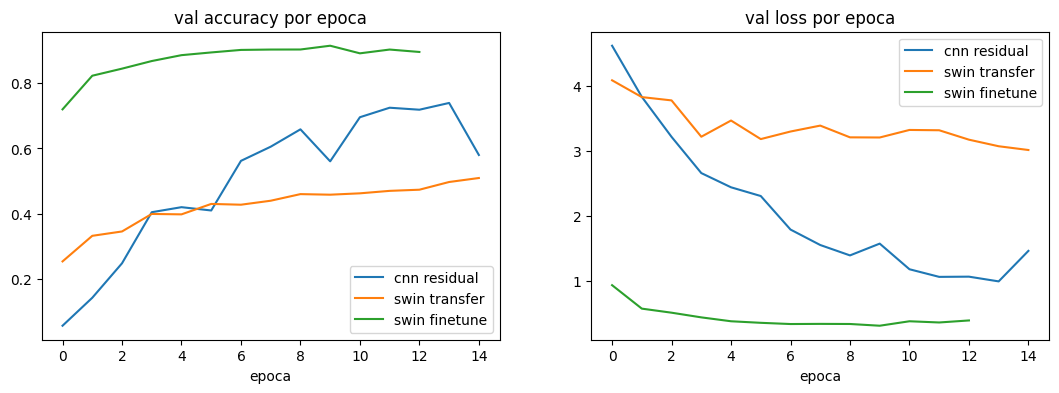

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))

axs[0].plot(hist_cnn['val_acc'], label='cnn residual')
axs[0].plot(hist_transfer['val_acc'], label='swin transfer')
axs[0].plot(hist_finetune['val_acc'], label='swin finetune')
axs[0].set_title('val accuracy por epoca')
axs[0].set_xlabel('epoca')
axs[0].legend()

axs[1].plot(hist_cnn['val_loss'], label='cnn residual')
axs[1].plot(hist_transfer['val_loss'], label='swin transfer')
axs[1].plot(hist_finetune['val_loss'], label='swin finetune')
axs[1].set_title('val loss por epoca')
axs[1].set_xlabel('epoca')
axs[1].legend()
plt.show()

evaluacion final en test (conjunto que ningun modelo vio hasta ahora), para los 3. cargamos el mejor checkpoint de cada uno (el que mejor val_acc dio durante el entrenamiento, no necesariamente el de la ultima epoca).

In [ ]:
def evaluate(model, ckpt_path):
    # carga el mejor checkpoint guardado y evalua sobre el test set completo
    model.load_state_dict(torch.load(ckpt_path))
    model.to(device)
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    with torch.no_grad():
        for x, y in dataloader_full['test']:
            x = x.to(device)
            out = model(x)
            probs = torch.softmax(out, dim=1)  # convertimos logits a probabilidades (necesario para roc-auc)
            y_probs.extend(probs.cpu().numpy())
            y_pred.extend(out.argmax(1).cpu().numpy())
            y_true.extend(y.numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_probs)

y_true_cnn, y_pred_cnn, probs_cnn = evaluate(cnn_model, 'cnn_residual.pt')
y_true_tr, y_pred_tr, probs_tr = evaluate(transfer_model, 'swin_transfer.pt')
y_true_ft, y_pred_ft, probs_ft = evaluate(finetune_model, 'swin_finetune.pt')

acc_cnn = accuracy_score(y_true_cnn, y_pred_cnn)
acc_tr = accuracy_score(y_true_tr, y_pred_tr)
acc_ft = accuracy_score(y_true_ft, y_pred_ft)
baseline_acc = 1 / len(CLASSES)  # baseline naive: predecir siempre la clase mas comun (aprox si estuviera balanceado)

print('accuracy cnn residual (test):', acc_cnn)
print('accuracy swin transfer (test):', acc_tr)
print('accuracy swin finetune (test):', acc_ft)
print('baseline naive (1/n clases):', baseline_acc)

accuracy cnn residual (test): 0.7306397306397306
accuracy swin transfer (test): 0.49975949975949974
accuracy swin finetune (test): 0.9163059163059163
baseline naive (1/n clases): 0.004048582995951417


precision, recall y f1 (macro, promediados entre todas las clases, para que clases con pocas imagenes pesen igual que las grandes).

In [ ]:
prec_cnn, rec_cnn, f1_cnn, _ = precision_recall_fscore_support(y_true_cnn, y_pred_cnn, average='macro', zero_division=0)
prec_tr, rec_tr, f1_tr, _ = precision_recall_fscore_support(y_true_tr, y_pred_tr, average='macro', zero_division=0)
prec_ft, rec_ft, f1_ft, _ = precision_recall_fscore_support(y_true_ft, y_pred_ft, average='macro', zero_division=0)

print('cnn residual   -> precision', prec_cnn, 'recall', rec_cnn, 'f1', f1_cnn)
print('swin transfer  -> precision', prec_tr, 'recall', rec_tr, 'f1', f1_tr)
print('swin finetune  -> precision', prec_ft, 'recall', rec_ft, 'f1', f1_ft)

cnn residual   -> precision 0.7698389018292201 recall 0.7247385216345401 f1 0.7221900589433802
swin transfer  -> precision 0.6093355135105635 recall 0.49916548404937316 f1 0.48013298189760834
swin finetune  -> precision 0.9262251296784381 recall 0.9182833305607284 f1 0.9189598078478326


matrices de confusion normalizadas (con tantas clases, mejor mirar la diagonal en un mapa de calor que numeros crudos): filas son la clase real, columnas la clase predicha, valores cerca de 1 en la diagonal significa buenos aciertos en esa clase.

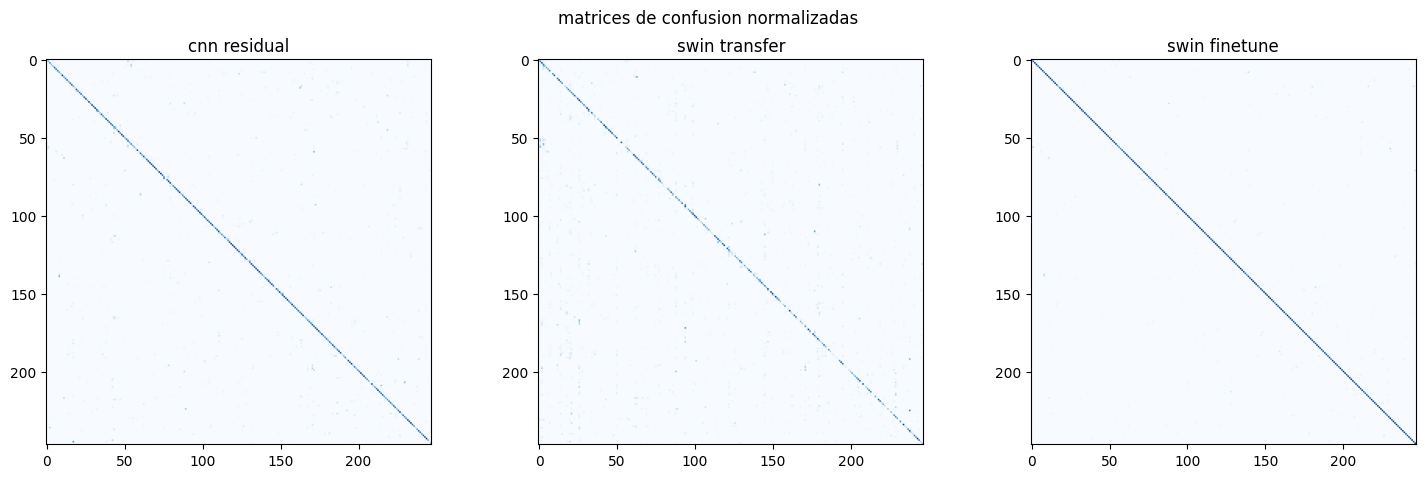

In [ ]:
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn, normalize='true')
cm_tr = confusion_matrix(y_true_tr, y_pred_tr, normalize='true')
cm_ft = confusion_matrix(y_true_ft, y_pred_ft, normalize='true')

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
axs[0].imshow(cm_cnn, cmap='Blues'); axs[0].set_title('cnn residual')
axs[1].imshow(cm_tr, cmap='Blues'); axs[1].set_title('swin transfer')
axs[2].imshow(cm_ft, cmap='Blues'); axs[2].set_title('swin finetune')
plt.suptitle('matrices de confusion normalizadas')
plt.show()

curva roc y auc multiclase (one vs rest: una curva por clase contra el resto, despues se promedia). el auc mide que tan bien separa el modelo cada clase del resto, 1.0 es separacion perfecta, 0.5 es equivalente a adivinar al azar. con 291 clases graficamos solo el promedio (micro-average) para que sea legible.

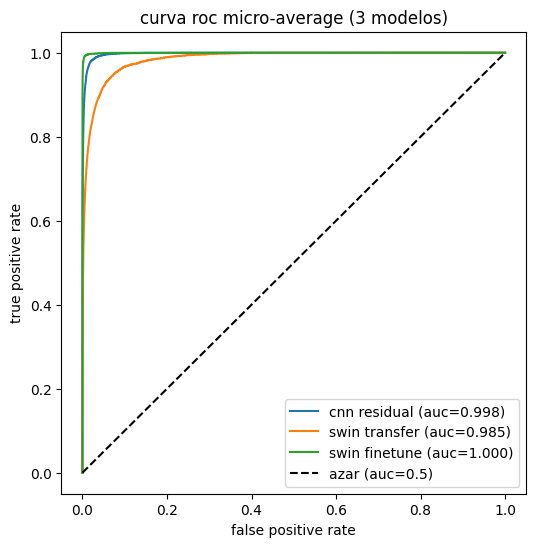

In [ ]:
def roc_auc_promedio(y_true, y_probs, n_classes):
    # binarizamos las clases (one-hot) para poder calcular una curva roc por clase
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    # roc micro-average: junta todas las clases en un solo calculo, da un resumen general
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

fpr_cnn, tpr_cnn, auc_cnn = roc_auc_promedio(y_true_cnn, probs_cnn, len(CLASSES))
fpr_tr, tpr_tr, auc_tr = roc_auc_promedio(y_true_tr, probs_tr, len(CLASSES))
fpr_ft, tpr_ft, auc_ft = roc_auc_promedio(y_true_ft, probs_ft, len(CLASSES))

plt.figure(figsize=(6, 6))
plt.plot(fpr_cnn, tpr_cnn, label=f'cnn residual (auc={auc_cnn:.3f})')
plt.plot(fpr_tr, tpr_tr, label=f'swin transfer (auc={auc_tr:.3f})')
plt.plot(fpr_ft, tpr_ft, label=f'swin finetune (auc={auc_ft:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='azar (auc=0.5)')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('curva roc micro-average (3 modelos)')
plt.legend()
plt.show()

comparacion final: parametros entrenables de cada modelo y todas las metricas juntas.

In [ ]:
params_cnn = sum(p.numel() for p in cnn_model.parameters())
params_tr = sum(p.numel() for p in transfer_model.parameters())
params_ft = sum(p.numel() for p in finetune_model.parameters())
# parametros que realmente se entrenaron (en transfer, la mayoria estan congelados)
trainable_tr = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)
trainable_ft = sum(p.numel() for p in finetune_model.parameters() if p.requires_grad)

print('parametros totales:')
print('  cnn residual:', params_cnn, '(todos entrenables)')
print('  swin transfer:', params_tr, '(entrenables:', trainable_tr, ')')
print('  swin finetune:', params_ft, '(entrenables:', trainable_ft, ')')
print()
print('accuracy test -> cnn:', acc_cnn, '| transfer:', acc_tr, '| finetune:', acc_ft)
print('f1 macro test -> cnn:', f1_cnn, '| transfer:', f1_tr, '| finetune:', f1_ft)
print('auc (micro)   -> cnn:', auc_cnn, '| transfer:', auc_tr, '| finetune:', auc_ft)

parametros totales:
  cnn residual: 2518039 (todos entrenables)
  swin transfer: 27709297 (entrenables: 189943 )
  swin finetune: 27709297 (entrenables: 27709297 )

accuracy test -> cnn: 0.7306397306397306 | transfer: 0.49975949975949974 | finetune: 0.9163059163059163
f1 macro test -> cnn: 0.7221900589433802 | transfer: 0.48013298189760834 | finetune: 0.9189598078478326
auc (micro)   -> cnn: 0.997750956852229 | transfer: 0.9845681994755863 | finetune: 0.999634680250361


resumen: la cnn residual se entrena desde cero con conexiones residuales (mismo principio que resnet, evita que el gradiente se degrade en redes profundas) y data augmentation, no tiene ningun conocimiento previo. swin transfer parte de pesos de imagenet pero con el backbone congelado, solo aprende la capa final, por eso entrena rapido pero tiene un techo mas bajo. swin finetune parte de los mismos pesos pero reajusta toda la red, por eso deberia dar el mejor resultado de los 3: combina el conocimiento previo de imagenet con la capacidad de adaptarse por completo al dominio especifico de escarabajos carabidos. con 291 especies muy parecidas entre si visualmente, se espera que el finetune marque la mayor diferencia.